# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [121]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

ERROR: Operation cancelled by user


In [122]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.2 which is incompatible.
bigframes 1.33.0 requires matplotlib>=3.7.1, but you have matplotlib 3.3.4 which is incompatible.
bigframes 1.33.0 requires pandas>=1.5.3, but you have pandas 1.5.2 which is incompatible.
albumentations 1.4.20 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
mlxtend 0.23.3 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
albucore 0.0.19 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
blosc2 3.0.0 requires numpy>=

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [123]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


os: Provides functions for interacting with the operating system (e.g., file handling).

numpy: Used for numerical operations and handling arrays/matrices.

pandas: Essential for data manipulation, especially for reading and processing CSV files.

matplotlib: A plotting library for visualizing data and images.

math: Provides mathematical functions (e.g., trigonometry, logarithms).

cv2 (OpenCV): Used for image processing and computer vision tasks.

seaborn: Built on top of matplotlib for more advanced statistical plotting.

In [124]:
# Standard Libraries
import os                   # For interacting with the operating system
import numpy as np          # For matrix operations and array manipulation
import pandas as pd         # For handling CSV files and dataframes
import matplotlib.pyplot as plt  # For plotting and visualizing data
import math                 # For mathematical functions and operations
import random               # For generating random values
import warnings             # To ignore warnings

# Image Processing and Visualization
import cv2                  # For image processing with OpenCV
import seaborn as sns       # For advanced plotting with seaborn
from google.colab.patches import cv2_imshow  # To display images in Google Colab

# TensorFlow and Keras for Deep Learning
import tensorflow as tf                            # TensorFlow for building deep learning models
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For image augmentation
from tensorflow.keras.models import Sequential                       # To define a neural network model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization  # Layers for CNN model
from tensorflow.keras.optimizers import Adam, SGD                     # Optimizers for training the model
from tensorflow.keras import backend                                        # Backend functions for deep learning

# Scikit-learn for Machine Learning
from sklearn import preprocessing                                  # For data preprocessing techniques
from sklearn.model_selection import train_test_split                # For splitting data into training and testing sets
from sklearn.metrics import confusion_matrix                        # For generating confusion matrix
from sklearn.preprocessing import LabelBinarizer                     # For converting labels to binary format

# Model Training and Optimization
from keras.callbacks import ReduceLROnPlateau                    # Callback for reducing learning rate during training
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.callbacks import EarlyStopping  #regularization method to prevent the overfitting
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix

In [125]:
# Load the dataset of images (numpy array format)
images = np.load('/content/drive/MyDrive/AIML_Project4/images.npy')  # Reading image data from .npy file

# Load the dataset of labels (CSV format)
labels = pd.read_csv('/content/drive/MyDrive/AIML_Project4/Labels.csv')  # Reading label data from .csv file


## Data Overview

### Understand the shape of the dataset

In [126]:
print(images.shape)
print(labels.shape)

(4750, 128, 128, 3)
(4750, 1)


images.shape: Displays the dimensions of the images array (e.g., number of images, image height, width, and number of channels).

labels.shape: Displays the dimensions of the labels array (e.g., number of labels corresponding to the number of images, and the format of the labels).

These commands help you quickly verify the structure and size of your datasets, ensuring they are in the correct format for model training.

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

In [127]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

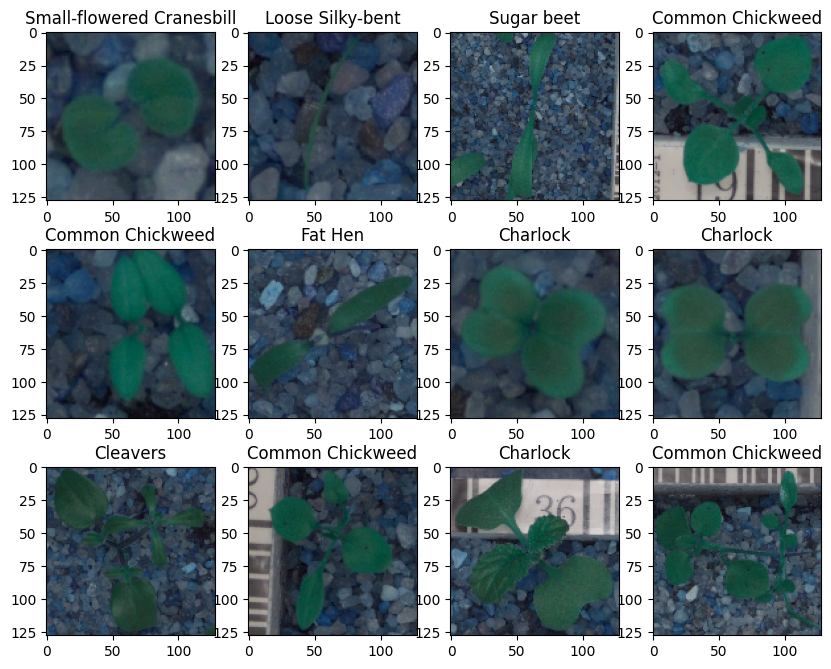

In [128]:
plot_images(images,labels)

(array([  0., 100., 200., 300., 400., 500., 600., 700.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

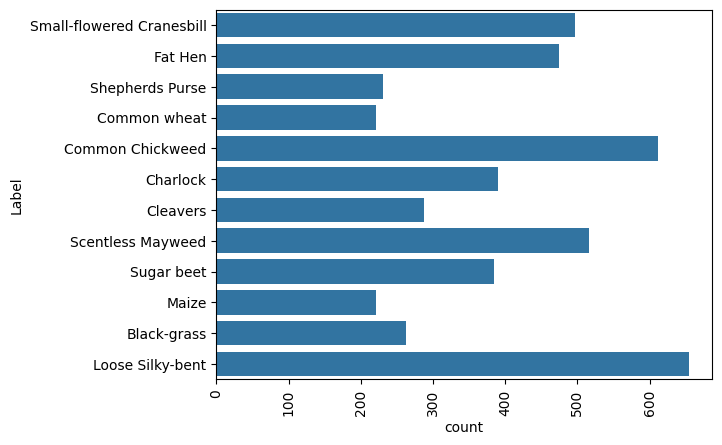

In [129]:
 sns.countplot(labels['Label'])
 plt.xticks(rotation='vertical')

Yes, the dataset appears to be imbalanced.

Bar Plot Analysis:

The bar plot shows the distribution of instances across different classes (labels). We can observe that some classes have significantly more instances compared to others. For example, "Loose Silky-bent" has a much higher count than "Maize" or "Charlock."

Implications of Imbalance:

An imbalanced dataset can pose challenges in machine learning model training and evaluation. Models might be biased towards the majority class, leading to poor performance on the minority classes.



## Data Pre-Processing

### Convert the BGR images to RGB images.


We can observe that the images are being shown in different colors when plotted with openCV and matplotlib as OpenCV reads images in BGR format and this shows that the given numpy arrays were generated from the original images using OpenCV.
Now we will convert these BGR images to RGB images so we could interpret them easily.

In [130]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

The code iterates through a list of images and converts each one from BGR (the default color format used by OpenCV) to RGB (a standard color format for image processing).

for i in range(len(images)):: Loops through each image in the images list.
cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB): Converts the i-th image from BGR to RGB using OpenCV's cvtColor function.

images[i] = ...: Updates the i-th image with the converted RGB version.
This process ensures that all images are in RGB format, which is often required for tasks like model training or visualization in libraries that expect RGB input.

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [131]:
images_decreased=[]
height = 64
width = 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append( cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

The code resizes all images in the images list to a new size of 64x64 pixels and stores them in the images_decreased list.

cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR): Resizes each image to the specified dimensions (64x64) using linear interpolation.
images_decreased.append(...): Adds the resized image to the images_decreased list.
This ensures that all images are uniformly resized to 64x64 pixels.

##**Image before resizing**

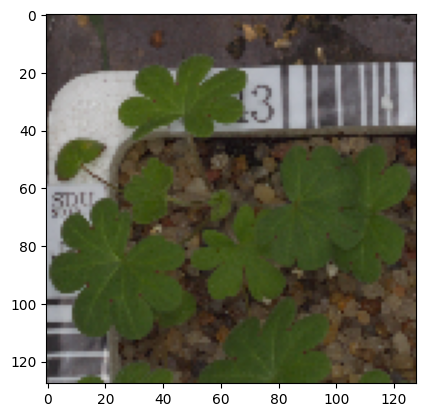

In [132]:
plt.imshow(images[3])

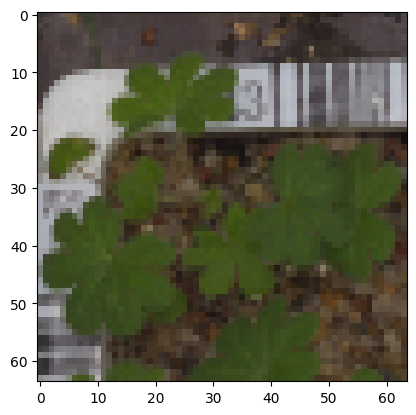

In [133]:
plt.imshow(images_decreased[3])

In [134]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images)):
  # gb[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
  images_gb.append(cv2.GaussianBlur(images[i], ksize =(3,3),sigmaX =  0))


## Visualizing images using Gaussian Blur

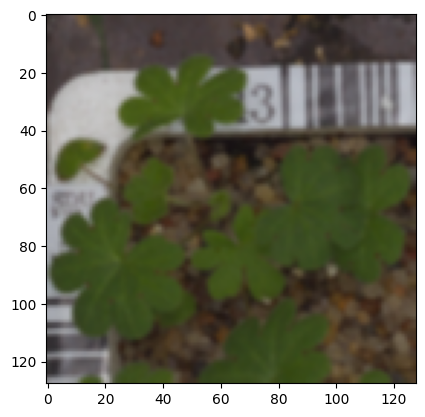

In [135]:
plt.imshow(images_gb[3])

It appears that GaussianBlur would be ineffective because the blurred or denoised image does not seem to contain any relevant information, and the model would struggle to categorize these blurred images.

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

## **Splitting the dataset**

As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [136]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),labels , test_size=0.1, random_state=42,stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp , test_size=0.1, random_state=42,stratify=y_temp)


In [137]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


### Encode the target labels

In [138]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

In [139]:
y_train_encoded.shape,y_val_encoded.shape,y_test_encoded.shape

((3847, 12), (428, 12), (475, 12))

In [140]:
y_train_encoded

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

### Data Normalization

##Importance of Data Normalization
(Scaling pixel values between 0 and 1):
Standardized Range: Pixel values in images typically range from 0 to 255. By dividing them by 255, you scale the values to a standardized range of 0 to 1. This makes it easier for machine learning models to process the data.

Faster Convergence: Normalizing the data helps the optimization algorithms converge faster during training, as large input values can lead to slower or less stable learning.

Improved Model Performance: Models like neural networks tend to perform better when the input data is normalized, as it prevents certain features from dominating due to large values.

Consistent Input: Many deep learning models assume that input data is on a similar scale. Normalization ensures that all images are treated equally, regardless of their original pixel intensity.

In [141]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0


## Model Building

## **Model Building - Convolutional Neural Network (CNN)**
Let's create a CNN model sequentially, where we will be adding the layers one after another.

First, we need to clear the previous model's history from the session even if a single model can run multiple times on the same data.

In Keras, we need a special command to clear the model's history, otherwise the previous model history remains in the backend.

Also, let's fix the seed again after clearing the backend.

Let's **set the seed for random number generators in Numpy, the Random library in Python, and in TensorFlow** to be able to reproduce the same results every time we run the code.

In [142]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [143]:
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

Now, let's build a **CNN Model** with the following 2 main parts - <br>

1. **The Feature Extraction layers** which are comprised of convolutional and pooling layers.
2. **The Fully Connected classification layers** for prediction.<br><br>


Filters: 64- Number of filters in the first hidden layer.This is also called as Kernel

Kernel_Size: The kernel size here refers to the widthxheight of the filter mask. The kernel_size must be an odd integer as well. Typical values for kernel_size include: (1, 1) , (3, 3) , (5, 5) , (7, 7)

Padding: The padding type is called SAME because the output size is the same as the input size(when stride=1). Using 'SAME' ensures that the filter is applied to all the elements of the input. Normally, padding is set to "SAME" while training the model. Output size is mathematically convenient for further computation.

MaxPool2D: Max Pooling is a pooling operation that calculates the maximum value for patches of a feature map, and uses it to create a downsampled (pooled) feature map. It is usually used after a convolutional layer.

Flatten: Flattening is converting the data into a 1-dimensional array for inputting it to the next layer. We flatten the output of the convolutional layers to create a single long feature vector. And it is connected to the final classification model, which is called a fully-connected layer.

In [144]:
# Intializing a sequential model
model1 = Sequential()                             # Complete the code to intialize a sequential model

# Complete the code to add the first conv layer with 128 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Complete the code to add the max pooling to reduce the size of output of first conv layer
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# Complete the code to create two similar convolution and max-pooling layers activation = relu
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding = 'same'))

# Complete the code to flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Complete the code to add a fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))
# Complete the code to add the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
model1.add(Dense(12, activation='softmax'))

# Complete the code to use the Adam Optimizer
opt=Adam()
# Complete the code to Compile the model using suitable metric for loss fucntion
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Complete the code to generate the summary of the model
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,172 (352.23 KB)

 Trainable params: 90,172 (352.23 KB)

 Non-trainable params: 0 (0.00 B)

### <b> Fitting the model on the train data

In [145]:
# Complete the code to fit the model on train and also using the validation data for validation
history_1 = model1.fit(
            X_train_normalized, y_train_encoded,
            epochs=30,
            validation_data=(X_val_normalized,y_val_encoded),
            batch_size=32,
            verbose=2
)

Epoch 1/30
121/121 - 15s - 128ms/step - accuracy: 0.1188 - loss: 2.4552 - val_accuracy: 0.2477 - val_loss: 2.3698
Epoch 2/30
121/121 - 1s - 12ms/step - accuracy: 0.2571 - loss: 2.1677 - val_accuracy: 0.3855 - val_loss: 1.8599
Epoch 3/30
121/121 - 3s - 21ms/step - accuracy: 0.3548 - loss: 1.8550 - val_accuracy: 0.4089 - val_loss: 1.6958
Epoch 4/30
121/121 - 1s - 7ms/step - accuracy: 0.3959 - loss: 1.7265 - val_accuracy: 0.4416 - val_loss: 1.6069
Epoch 5/30
121/121 - 1s - 10ms/step - accuracy: 0.4232 - loss: 1.6041 - val_accuracy: 0.5304 - val_loss: 1.4135
Epoch 6/30
121/121 - 2s - 13ms/step - accuracy: 0.4487 - loss: 1.5118 - val_accuracy: 0.5561 - val_loss: 1.2904
Epoch 7/30
121/121 - 2s - 13ms/step - accuracy: 0.4684 - loss: 1.4231 - val_accuracy: 0.5864 - val_loss: 1.2416
Epoch 8/30
121/121 - 1s - 7ms/step - accuracy: 0.4913 - loss: 1.3846 - val_accuracy: 0.6192 - val_loss: 1.1398
Epoch 9/30
121/121 - 1s - 7ms/step - accuracy: 0.5108 - loss: 1.3402 - val_accuracy: 0.6075 - val_loss: 

### **Model Evaluation**

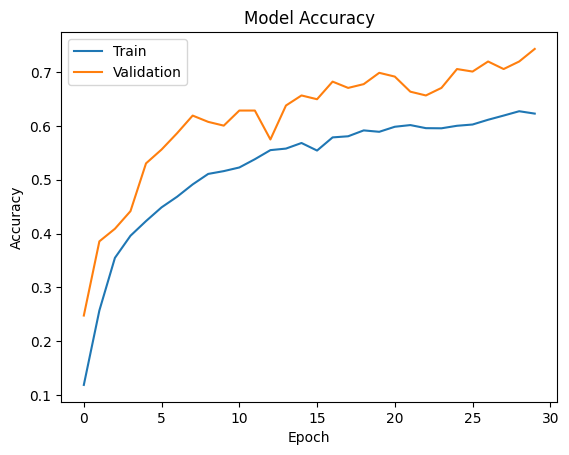

In [146]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Observations:

Overall Trend: Both the training accuracy and validation accuracy show an upward trend, indicating that the model is learning and improving over the epochs.

Gap Between Training and Validation: There is a noticeable gap between the training accuracy and validation accuracy. This gap suggests that the model might be overfitting to the training data. Overfitting occurs when the model learns the training data too well, but struggles to generalize to unseen data (like the validation set).

Early Stopping: It's important to consider early stopping. If the validation accuracy stops improving or starts to decrease, even though the training accuracy continues to rise, it's a sign of overfitting. In such cases, early stopping would prevent further training and help avoid overfitting.

#### Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

### **Evaluating the model on test data**

In [147]:
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 0s - 31ms/step - accuracy: 0.7095 - loss: 0.9371


In [148]:
y_pred=model1.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [149]:
y_pred

array([[3.4384489e-14, 9.6893835e-15, 2.0665940e-17, ..., 7.7071891e-04,
        1.4366071e-11, 8.6575365e-06],
       [3.6569709e-09, 2.8928738e-02, 4.6537402e-03, ..., 2.6792012e-02,
        8.3463556e-01, 5.1911276e-02],
       [1.6778350e-07, 7.7941210e-04, 3.5541561e-05, ..., 5.7088714e-03,
        9.2774487e-01, 6.0428381e-02],
       ...,
       [2.3641291e-01, 1.3815902e-13, 2.0247533e-07, ..., 1.6513305e-10,
        9.6267117e-10, 7.0302391e-09],
       [3.5073437e-08, 4.6242371e-07, 1.9792853e-07, ..., 8.5789569e-02,
        1.6180914e-07, 2.8634351e-03],
       [5.9814438e-11, 8.1248902e-04, 7.1424649e-05, ..., 6.6770560e-01,
        2.4545830e-02, 1.1330715e-02]], dtype=float32)

The Confusion matrix is also defined as an inbuilt function in the TensorFlow module, so we can use that for evaluating the classification model.
The Confusion matrix expects categorical data as input. However, y_test_encoded is an encoded value, whereas y_pred has probabilities. So,we must retrieve the categorical values from the encoded values.
We will use the argmax() function to obtain the maximum value over each category on both y_test_encoded and y_pred and obtain their respective classes.

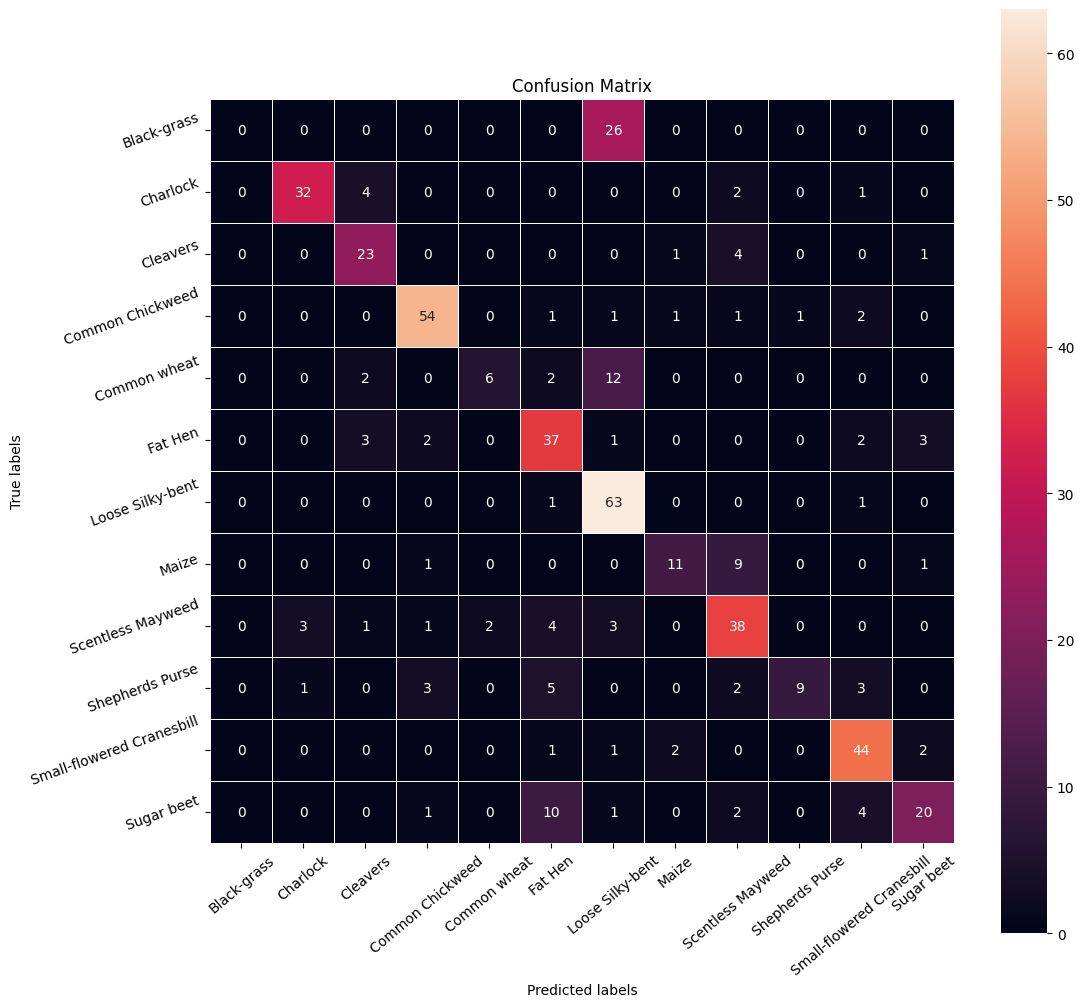

In [150]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)            # Complete the code to plot the confusion matrix
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

## Classification Report - Model1 Basic CNN  Model


In [151]:
from sklearn.metrics import classification_report
print(classification_report(y_test_arg,y_pred_arg))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.89      0.82      0.85        39
           2       0.70      0.79      0.74        29
           3       0.87      0.89      0.88        61
           4       0.75      0.27      0.40        22
           5       0.61      0.77      0.68        48
           6       0.58      0.97      0.73        65
           7       0.73      0.50      0.59        22
           8       0.66      0.73      0.69        52
           9       0.90      0.39      0.55        23
          10       0.77      0.88      0.82        50
          11       0.74      0.53      0.62        38

    accuracy                           0.71       475
   macro avg       0.68      0.63      0.63       475
weighted avg       0.69      0.71      0.68       475



#### Comments on the model

The confusion matrix shows that the model is performing well in identifying certain classes, but struggling with others. Here's a breakdown:

Correctly Identified Classes:

Classes with high diagonal values: Classes 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, and 11 all have high values on the diagonal, indicating that the model is correctly classifying most instances of these classes.
Misclassified Classes:

Class 1: There are a significant number of instances of class 0 being misclassified as class 6. This suggests that the model is having difficulty distinguishing between these two classes.
Other Misclassifications: There are also some misclassifications between other classes, although to a lesser extent. For example, class 4 is sometimes misclassified as class 6, and class 8 is occasionally misclassified as class 7.
Overall, the model appears to be more accurate in identifying certain classes than others. Further analysis and potential adjustments to the model or data might be necessary to improve its performance on the misclassified classes.

# Model 2 CNN with Data Augmentation + Adam with learning rate adjustment

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

# Model 2 CNN with Data Augmentation + Adam with learning rate adjustment
As we can see, our initial model appears to overfit. Therefore we'll try to address this problem with data augmentation and Batch Normalization to check if we can improve the model's performance

##### We will use reduce learning rate
Use ReduceLRonPlateau() function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

#### **Data Augmentation**

In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs. To overcome this problem, one approach we might consider is **Data Augmentation**. CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. <br> Taking this attribute into account, we can augment the images using the techniques listed below - <br>
**1. Horizontal Flip** (should be set to True/False) <br>
**2. Vertical Flip** (should be set to True/False) <br>
**3. Height Shift** (should be between 0 and 1) <br>
**4. Width Shift** (should be between 0 and 1) <br>
**5. Rotation** (should be between 0 and 180) <br>
**6. Shear** (should be between 0 and 1) <br>
**7. Zoom** (should be between 0 and 1) etc. <br>

Remember, **data augmentation should not be used in the validation/test data set**.

In [152]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#### We will use reduce learning rate
Use ReduceLRonPlateau() function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [153]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)


#### Explanation on the parameters:

It monitors the val_accuracy (validation accuracy) during training to decide when to reduce the learning rate.

patience=3:
This means the learning rate will only be reduced if the validation accuracy doesn't improve for 3 consecutive epochs.

verbose=1:
This enables a message to be printed when the learning rate is reduced.

factor=0.5:
This reduces the learning rate by a factor of 0.5 (i.e., halving the learning rate) when the val_accuracy stops improving.

min_lr=0.00001:
This sets the minimum value the learning rate can reach. The learning rate will not be reduced below this threshold.

In [154]:
# All images to be rescaled by 1/255.
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )
# test_datagen  = ImageDataGenerator(rescale = 1.0/255.)

train_datagen: Applies data augmentation (rotation) to training images.

test_datagen: Rescales test images to the [0, 1] range for normalization.

1. Initializing the Model:
model2 = Sequential(): Initializes a sequential model, where layers are stacked on top of each other in a linear fashion.
2. Adding Layers:
    Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)):

    Conv2D: Adds a 2D convolutional layer with 64 filters, each of size 3x3.
    activation='relu': Uses the ReLU activation function to introduce non-linearity.
    padding="same": Ensures that the output feature map has the same width and height as the input by padding the image if necessary.
    input_shape=(64, 64, 3): Specifies the input dimensions (64x64 pixels, 3 color channels).
    MaxPooling2D((2, 2), padding='same'):

    Applies max pooling to reduce the spatial dimensions (height and width) by a factor of 2, with padding to retain the output size.
    Second Conv2D and MaxPooling2D: A second convolutional layer with 32 filters, followed by another max-pooling layer.

    BatchNormalization(): Normalizes the activations, stabilizing the learning process and speeding up training.

    Flatten(): Flattens the multi-dimensional output of the convolutional layers into a 1D array, making it ready for the fully connected (dense) layers.

    Dense(16, activation='relu'): A fully connected layer with 16 neurons and ReLU activation.

    Dropout(0.3): A dropout layer that randomly sets 30% of the neurons to zero during training, which helps prevent overfitting.

    Dense(12, activation='softmax'): The output layer with 12 neurons (for a multi-class classification task) and a softmax activation function to output class probabilities.

3. Compiling the Model:
optimizer=Adam(): Uses the Adam optimizer, a popular choice for deep learning tasks that adapts the learning rate during training.
loss='categorical_crossentropy': Specifies categorical cross-entropy loss for multi-class classification problems.
metrics=['accuracy']: Tracks accuracy as the performance metric during training.
4. Model Summary:
model2.summary(): Displays a summary of the model architecture, showing the details of each layer, including the number of parameters.

In [155]:
# Intializing a sequential model
model2 = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension images
model2.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model2.add(MaxPooling2D((2, 2), padding = 'same'))
# model.add(BatchNormalization())
model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model2.add(MaxPooling2D((2, 2), padding = 'same'))
model2.add(BatchNormalization())
# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model2.add(Flatten())

# Adding a fully connected dense layer with 100 neurons
model2.add(Dense(16, activation='relu'))
model2.add(Dropout(0.3))
# Adding the output layer with 10 neurons and activation functions as softmax since this is a multi-class classification problem
model2.add(Dense(12, activation='softmax'))

# Using SGD Optimizer
# opt = SGD(learning_rate=0.01, momentum=0.9)
opt=Adam()
# Compile model
model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

In [156]:
# Complete the code to fit the model on train data with batch_size=64 and epochs=30
# Epochs
epochs = 30
# Batch size
batch_size = 64

history_2 = model2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       shuffle=False),
                                       epochs=epochs,
                                       steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.1623 - loss: 2.4061 - val_accuracy: 0.1589 - val_loss: 2.4041 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3438 - loss: 2.0016 - val_accuracy: 0.1822 - val_loss: 2.4084 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.3815 - loss: 1.8540 - val_accuracy: 0.2897 - val_loss: 2.3756 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4219 - loss: 1.6613 - val_accuracy: 0.2967 - val_loss: 2.3642 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.4518 - loss: 1.6467 - val_accuracy: 0.4206 - val_loss: 2.2515 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4062 - loss: 1.7302 - val_accuracy: 0.3925 - val_loss: 2.2447 - learning_rate: 0.0010
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.4943 - loss: 1.5223 - val_accur

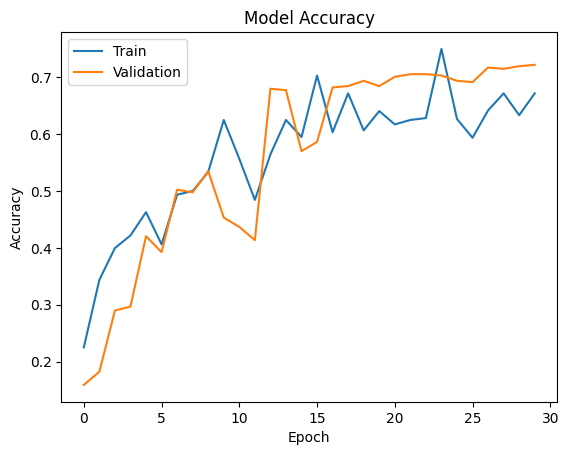

In [157]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [158]:
accuracy = model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 34ms/step - accuracy: 0.7347 - loss: 0.9068


In [159]:
# Here we would get the output as probablities for each category
y_pred=model2.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


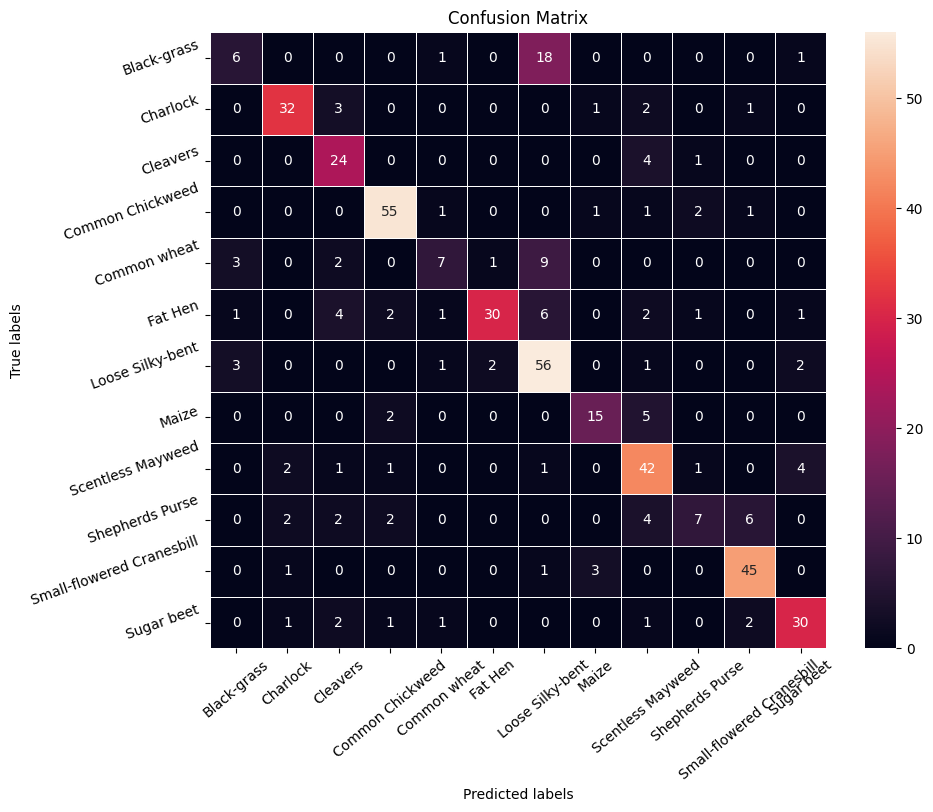

In [160]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

# Classification Report - Model 2 CNN with Data Augmentation + Adam with learning rate adjustment

In [161]:
from sklearn.metrics import classification_report
print(classification_report(y_test_arg,y_pred_arg))

              precision    recall  f1-score   support

           0       0.46      0.23      0.31        26
           1       0.84      0.82      0.83        39
           2       0.63      0.83      0.72        29
           3       0.87      0.90      0.89        61
           4       0.58      0.32      0.41        22
           5       0.91      0.62      0.74        48
           6       0.62      0.86      0.72        65
           7       0.75      0.68      0.71        22
           8       0.68      0.81      0.74        52
           9       0.58      0.30      0.40        23
          10       0.82      0.90      0.86        50
          11       0.79      0.79      0.79        38

    accuracy                           0.73       475
   macro avg       0.71      0.67      0.68       475
weighted avg       0.73      0.73      0.72       475



# Model 3 Using Transfer Learning using VGG16

In [162]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [163]:
from tensorflow.keras import backend
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

- Let's try again, but this time, we will be using the idea of **Transfer Learning**. We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will replace the existing fully-connected layers with FC layers created specifically for our problem.


In [164]:
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

vgg_model = VGG16(weights='imagenet', include_top = False, input_shape = (64,64,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

#### Why Freeze the Layers?
Freezing the layers of the pre-trained VGG model is a common technique used in transfer learning. The idea is that the pre-trained model has already learned useful features (such as edges, textures, and patterns) from a large dataset like ImageNet. By freezing these layers:

You prevent these learned features from being altered during training.
You can save time and computational resources since the lower-level features are already learned.
You only train the new layers that you add on top of the frozen model, which typically speeds up the training process and reduces overfitting.

In [166]:
model3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model3.add(Flatten())

# Adding a dense output layer
model3.add(Dense(32, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(12, activation='softmax'))
opt=Adam()
# Compile model
model3.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 2, 2, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          65,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,988 (56.38 MB)

 Trainable params: 66,300 (258.98 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [167]:
# Epochs
epochs = 30
# Batch size
batch_size = 64

history_vgg16 = model3.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       shuffle=False),
                                       epochs=epochs,
                                       steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.1227 - loss: 2.4590 - val_accuracy: 0.3061 - val_loss: 2.1480 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2656 - loss: 2.1413 - val_accuracy: 0.3201 - val_loss: 2.1476 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.2767 - loss: 2.0979 - val_accuracy: 0.3832 - val_loss: 1.9041 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3125 - loss: 2.0414 - val_accuracy: 0.3785 - val_loss: 1.9041 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.3472 - loss: 1.8825 - val_accuracy: 0.3925 - val_loss: 1.7788 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3594 - loss: 1.8018 - val_accuracy: 0.3925 - val_loss: 1.7784 - learning_rate: 0.0010
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.3789 - loss: 1.7655 - val_acc

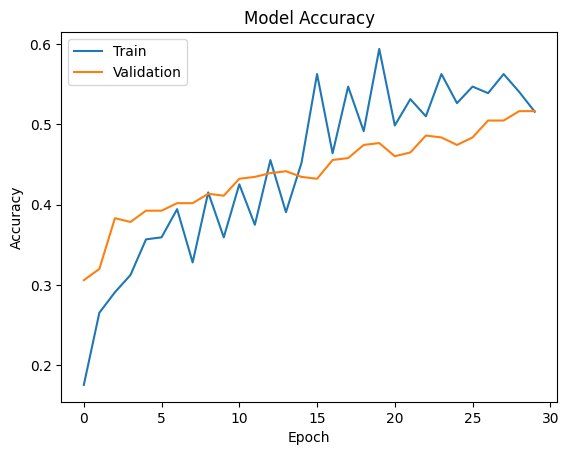

In [168]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [169]:
accuracy = model3.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 44ms/step - accuracy: 0.5326 - loss: 1.3551


In [170]:
# Here we would get the output as probablities for each category
y_pred=model3.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


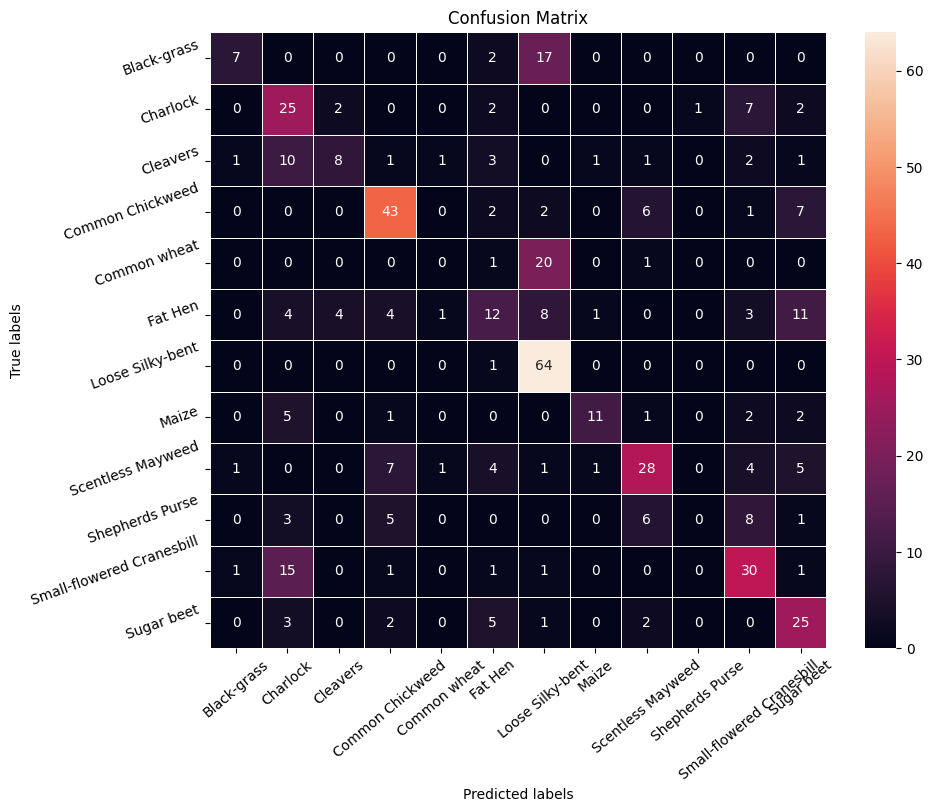

In [171]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

#Classification Report - Model 3 Using Transfer Learning using VGG16

In [172]:
from sklearn.metrics import classification_report
print(classification_report(y_test_arg,y_pred_arg))

              precision    recall  f1-score   support

           0       0.70      0.27      0.39        26
           1       0.38      0.64      0.48        39
           2       0.57      0.28      0.37        29
           3       0.67      0.70      0.69        61
           4       0.00      0.00      0.00        22
           5       0.36      0.25      0.30        48
           6       0.56      0.98      0.72        65
           7       0.79      0.50      0.61        22
           8       0.62      0.54      0.58        52
           9       0.00      0.00      0.00        23
          10       0.53      0.60      0.56        50
          11       0.45      0.66      0.54        38

    accuracy                           0.53       475
   macro avg       0.47      0.45      0.44       475
weighted avg       0.50      0.53      0.49       475



#Model 4 Data Augmentation with SGD

In [173]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [174]:

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [175]:
# Intializing a sequential model
model4 = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of MNIST images
model4.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64,64,3)))

# Adding max pooling to reduce the size of output of first conv layer
model4.add(MaxPooling2D((2, 2), padding = 'same'))

model4.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model4.add(MaxPooling2D((2, 2), padding = 'same'))
model4.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model4.add(MaxPooling2D((2, 2), padding = 'same'))

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model4.add(Flatten())

# Adding a fully connected dense layer with 100 neurons
model4.add(Dense(16, activation='relu'))

# Adding the output layer with 10 neurons and activation functions as softmax since this is a multi-class classification problem
model4.add(Dense(12, activation='softmax'))

# Using SGD Optimizer
opt = SGD(learning_rate=0.01, momentum=0.9)

# Compile model
model4.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,492 (244.11 KB)

 Trainable params: 62,492 (244.11 KB)

 Non-trainable params: 0 (0.00 B)

In [176]:
# Complete the code to fit the model on train data with batch_size=64 and epochs=30
# Epochs
epochs = 30
# Batch size
batch_size = 64

history_4 = model4.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       shuffle=False),
                                       epochs=epochs,
                                       steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                                       validation_data=(X_val_normalized,y_val_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.1083 - loss: 2.4642 - val_accuracy: 0.1285 - val_loss: 2.4275 - learning_rate: 0.0100
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1719 - loss: 2.4248 - val_accuracy: 0.1262 - val_loss: 2.4277 - learning_rate: 0.0100
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.1250 - loss: 2.4197 - val_accuracy: 0.1379 - val_loss: 2.4194 - learning_rate: 0.0100
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1250 - loss: 2.4672 - val_accuracy: 0.1379 - val_loss: 2.4197 - learning_rate: 0.0100
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.1307 - loss: 2.4188 - val_accuracy: 0.1379 - val_loss: 2.4167 - learning_rate: 0.0100
Epoch 6/30
 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0938 - loss: 2.4543
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0938 - loss: 2.4543 - val_accurac

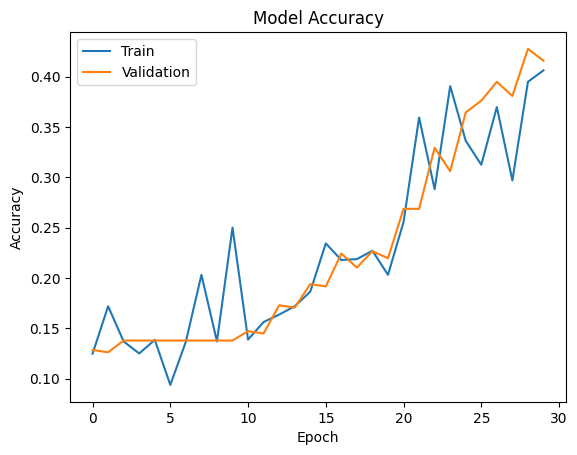

In [177]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [178]:
accuracy = model4.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 0s - 22ms/step - accuracy: 0.4021 - loss: 1.7031


In [179]:
# Here we would get the output as probablities for each category
y_pred=model4.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


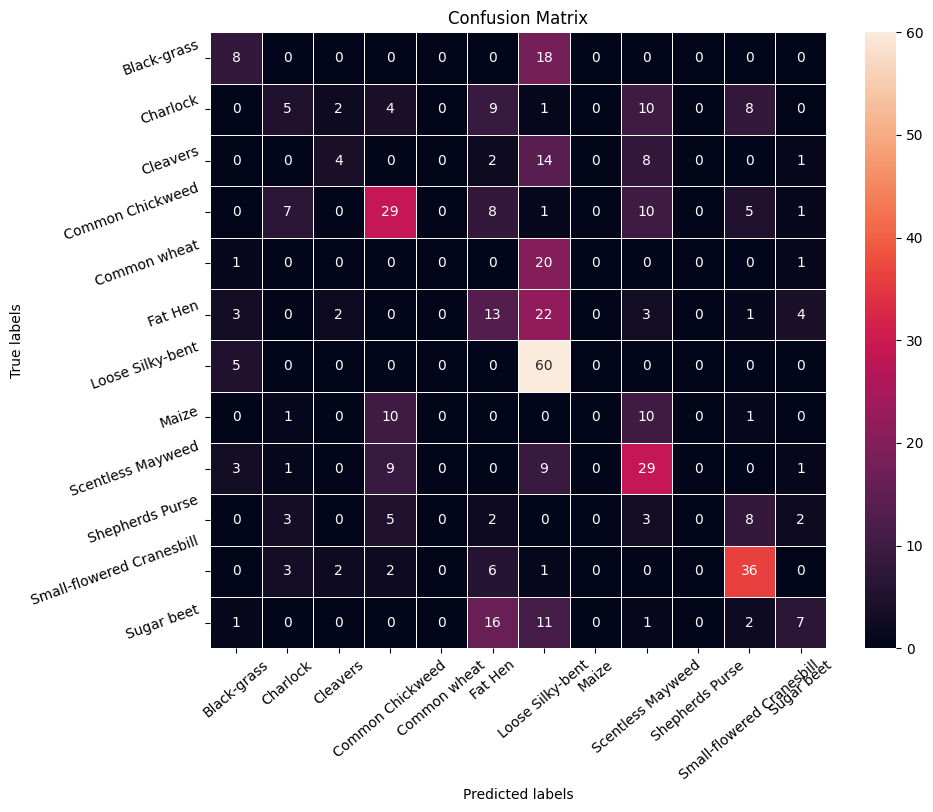

In [180]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

# Classification Report -Model 4 Data Augmentation with SGD

In [181]:
from sklearn.metrics import classification_report
print(classification_report(y_test_arg,y_pred_arg))

              precision    recall  f1-score   support

           0       0.38      0.31      0.34        26
           1       0.25      0.13      0.17        39
           2       0.40      0.14      0.21        29
           3       0.49      0.48      0.48        61
           4       0.00      0.00      0.00        22
           5       0.23      0.27      0.25        48
           6       0.38      0.92      0.54        65
           7       0.00      0.00      0.00        22
           8       0.39      0.56      0.46        52
           9       0.00      0.00      0.00        23
          10       0.59      0.72      0.65        50
          11       0.41      0.18      0.25        38

    accuracy                           0.40       475
   macro avg       0.29      0.31      0.28       475
weighted avg       0.34      0.40      0.35       475



## Final Model

### Visualizing the prediction

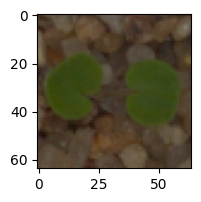

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


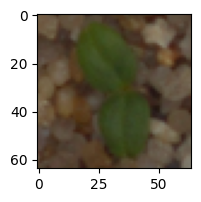

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Label ['Cleavers']
True Label Cleavers


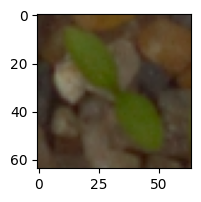

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted Label ['Common Chickweed']
True Label Common Chickweed


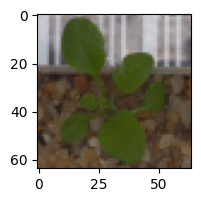

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Shepherds Purse


In [182]:

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[59],)
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[36])                                              # using inverse_transform() to get the output label from the output vector

## Summary

I evaluated the performance using four models:

Basic CNN model
CNN model with Adam optimizer and dynamic learning rate
CNN model with VGG16 using transfer learning
CNN model with SGD optimizer
The results were as follows:

The Basic CNN model achieved 71% test accuracy.
The CNN model with Adam and dynamic learning rate gave 74% test accuracy.
The CNN model with VGG16 using transfer learning resulted in 54% test accuracy.
The CNN model with SGD optimizer performed the worst, with only 41% test accuracy.
Based on these results, Model 2 (CNN with Adam and dynamic learning rate) performed the best, providing the most reliable results.

In [187]:
pd.DataFrame({'Models':['Base CNN Model','CNN Model with Data Augmentation','Transfer Learning Model', 'CNN Model with Data Augmentation with SGD'],'Train Accuracy':['63%','68%','52%','41%'],'Validation Accuracy':['74%','73%','52%','42'],'Test Accuracy':['71%','74%','54%','41%']})

,Models,Train Accuracy,Validation Accuracy,Test Accuracy
0,Base CNN Model,63%,74%,71%
1,CNN Model with Data Augmentation,68%,73%,74%
2,Transfer Learning Model,52%,52%,54%
3,CNN Model with Data Augmentation with SGD,41%,42,41%


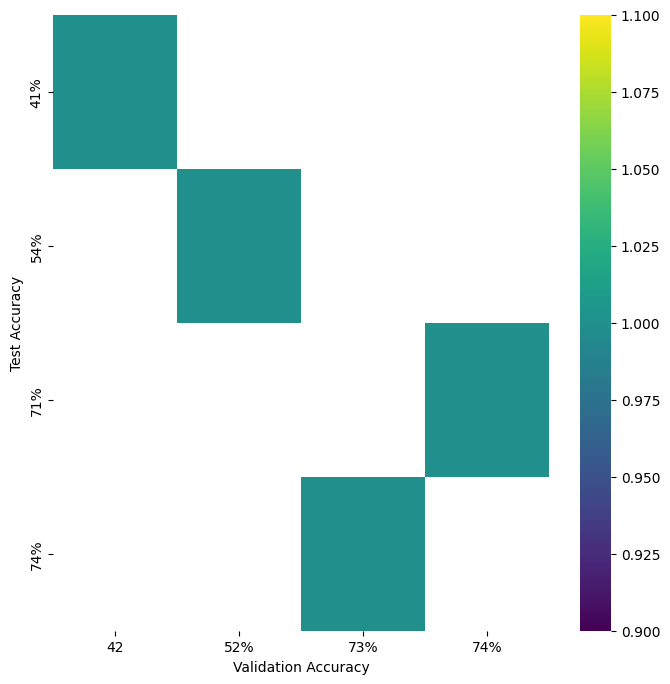

In [188]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Test Accuracy'].value_counts()
    for x_label, grp in _df_6.groupby('Validation Accuracy')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Validation Accuracy')
_ = plt.ylabel('Test Accuracy')

## Actionable Insights and Business Recommendations

## Scope of Improvement
- These models can be further improved by training with different filter sizes and different number of filters.
- Data Augmentation can be performed more and dropout_rate can be changed to improve the model performance.
- Other Transfer Learning architectures can also be used to train the CNN model and these models can be used for classification.
-There is still scope for improvement in the test accuracy of the CNN model chosen here. Different architectures and optimizers can be used to built to obtain a better classifier.

#### Applications

1. Automation of Seedling Identification
Recommendation: Leverage the model to automate the identification of plant species in agricultural fields, reducing the need for manual labor in plant classification. This would improve the efficiency of agricultural workers by helping them quickly categorize plants, which is especially useful in large-scale farming operations.
Business Impact: Reduced operational costs, faster identification, and better resource allocation for farmers.
2. Crop Monitoring and Decision-Making
Recommendation: Use the model to monitor crop health by identifying various plant species at different growth stages. This could be integrated into precision farming tools to detect early signs of plant diseases or pests based on plant type, thus enabling proactive interventions.
Business Impact: Higher crop yields, reduced pesticide use, and more sustainable farming practices.
3. Expanding to Additional Plant Species
Recommendation: Enhance the model's performance by training it on additional plant species or by using transfer learning to further fine-tune the model with more diverse datasets. Expanding its scope could increase its value in different agricultural sectors.
Business Impact: Broader applicability of the solution, catering to a larger market in the agricultural industry.
4. Deployment in Mobile or IoT Devices
Recommendation: Implement the model into mobile applications or IoT devices used by farmers in the field, providing real-time classification of seedlings via smartphones or tablets.
Business Impact: Increase accessibility for farmers, especially in remote areas, and improve real-time decision-making capabilities.
5. Collaborating with Agricultural Startups or Organizations
Recommendation: Collaborate with agricultural technology companies or startups that focus on AI-driven solutions for farming. By integrating this model into their existing platforms, it can contribute to more intelligent and scalable agricultural operations.
Business Impact: Access to a broader client base, strategic partnerships, and potential market growth.
6. Continuous Model Improvement
Recommendation: Given the current 74% accuracy, further refinement of the model (e.g., with more data, improved architectures, or fine-tuning) can improve its accuracy and performance, making it more reliable in production settings.
Business Impact: Enhanced trust in the system, improved outcomes for end-users, and a higher adoption rate within the agricultural industry.

*

_____